
Processing system: PE-A1
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica1/linear.lammpstrj
  replica = 1
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica2/linear.lammpstrj
  replica = 2
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica3/linear.lammpstrj
  replica = 3
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240

Processing system: PE-A2
Reading: /blue/jsampath/avemula/Paper1_PE/

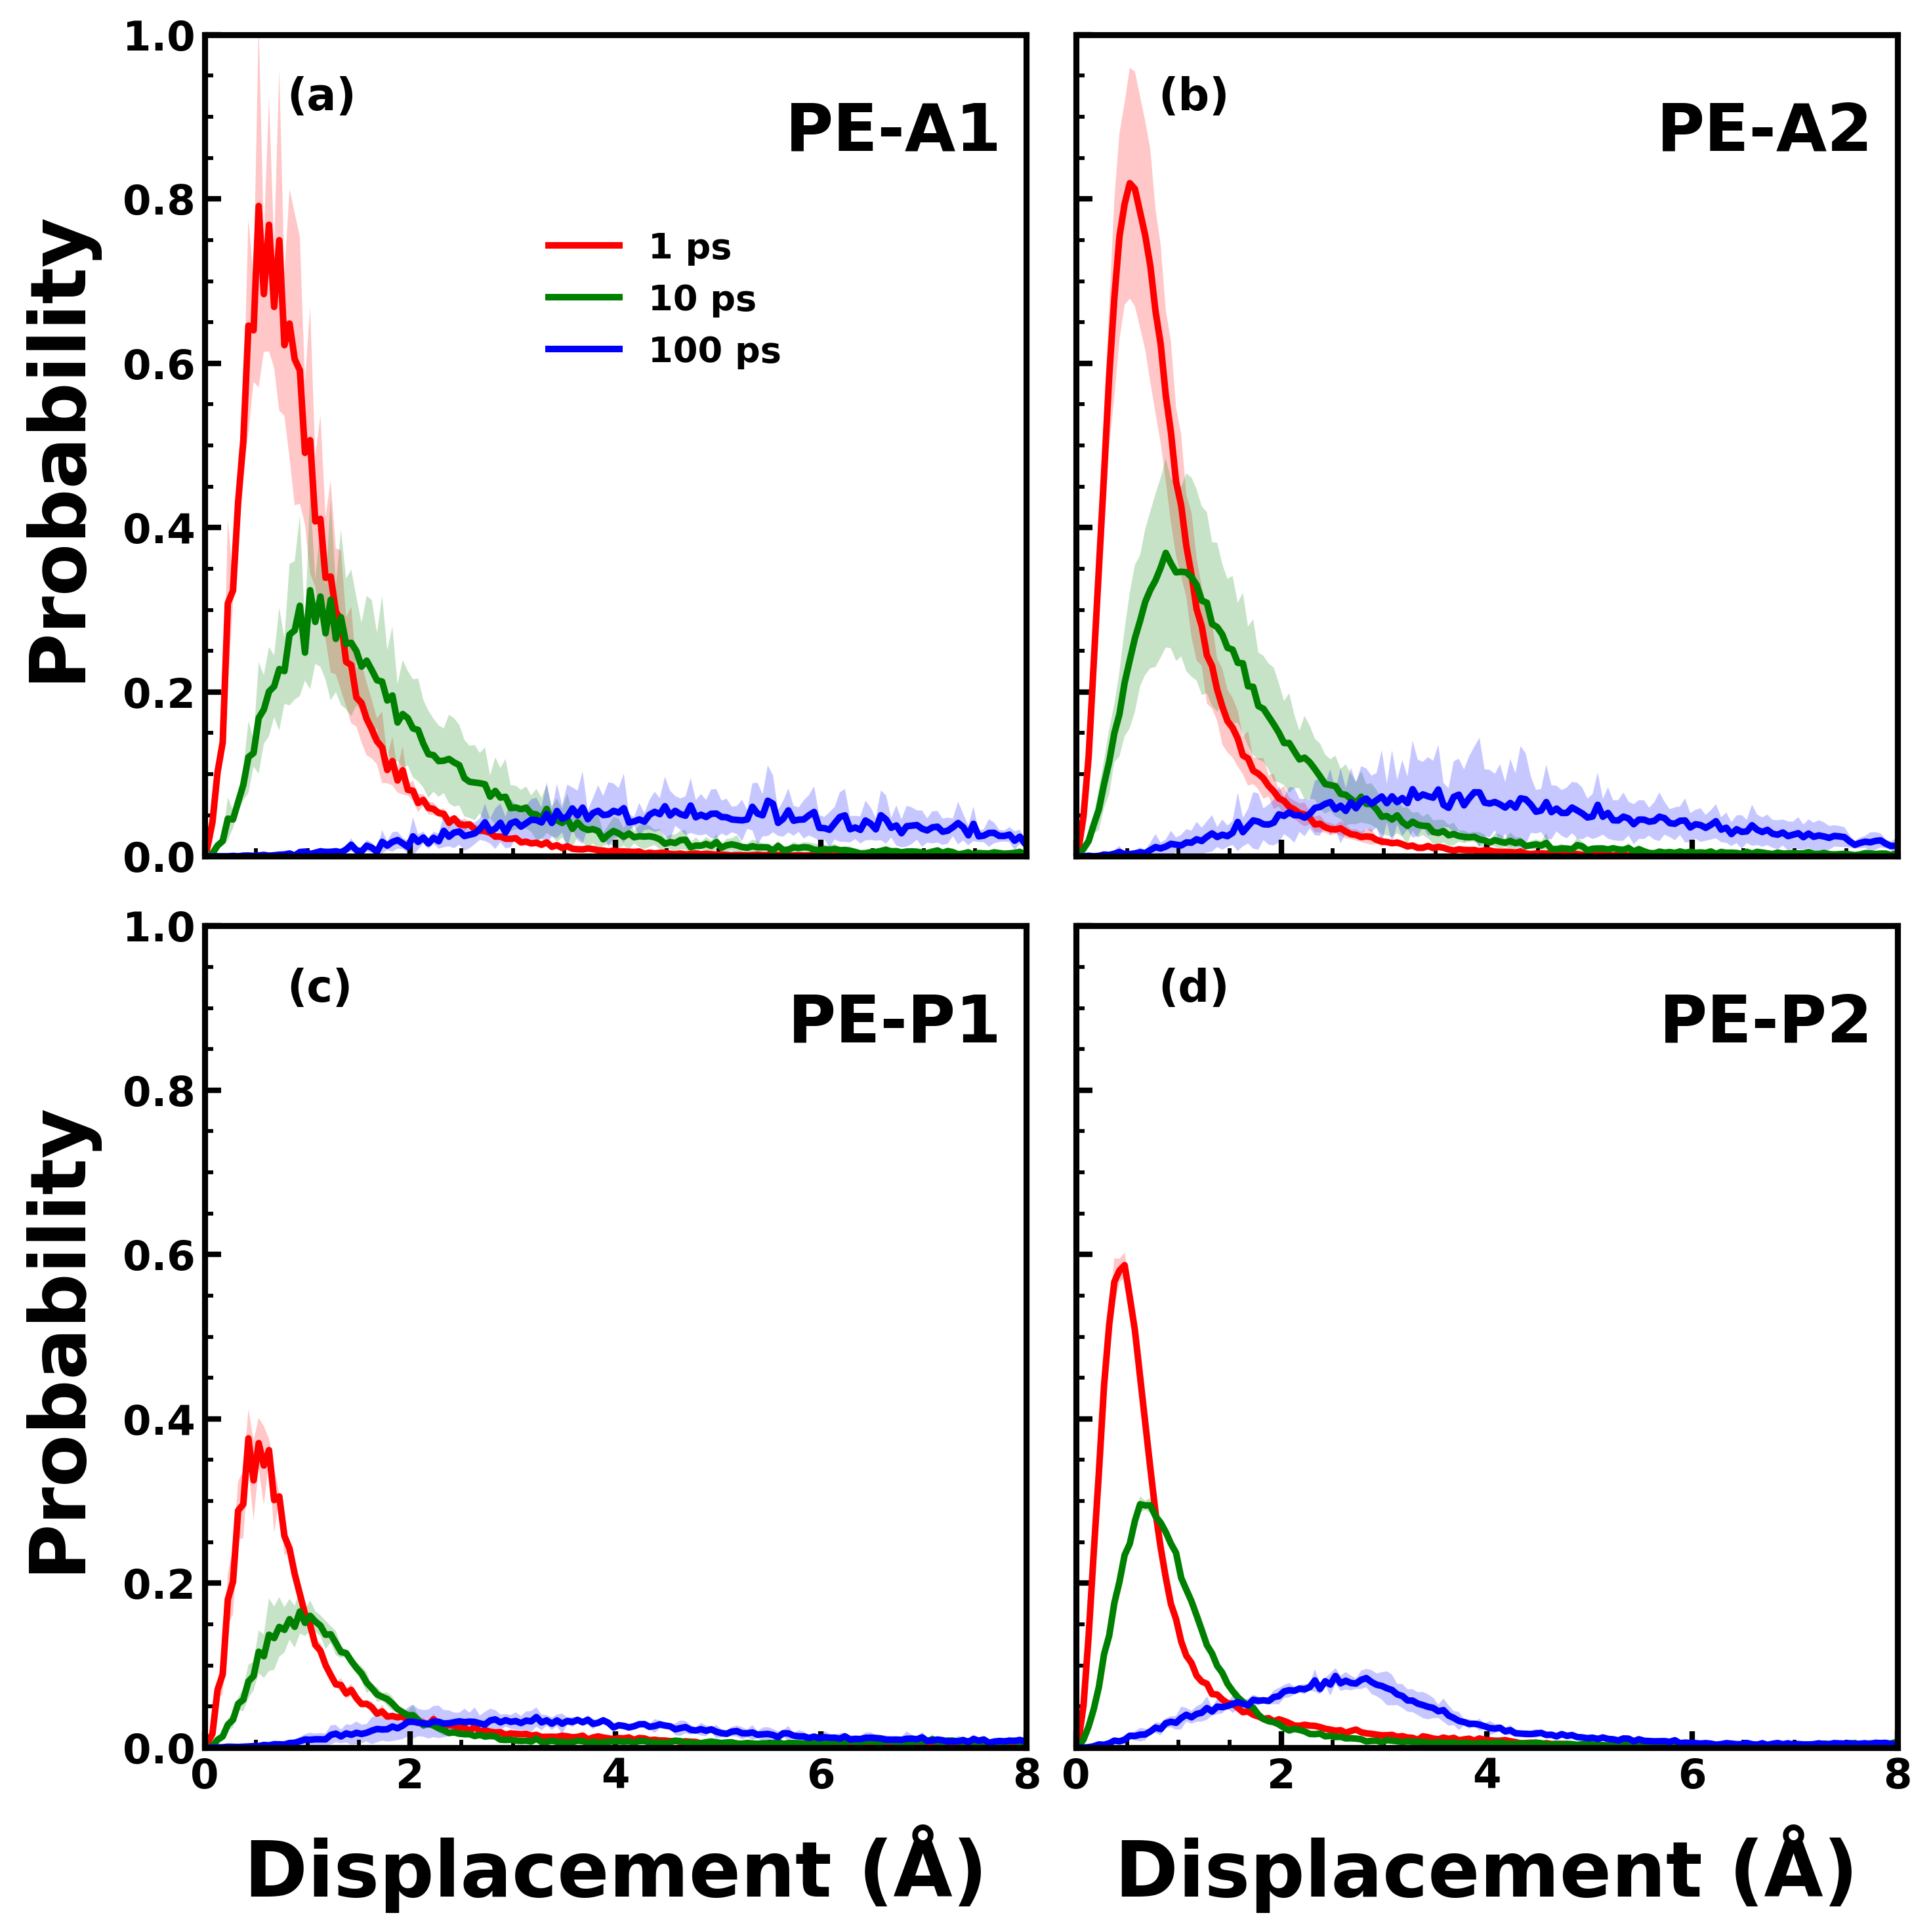


Saved:
displacement_distribution_2x2_ACSbold.png
displacement_distribution_2x2_ACSbold.pdf


In [ ]:
#!/usr/bin/env python3



import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# SETTINGS
# =========================================================
BASE = "/blue/jsampath/avemula/Paper1_PE/Polymer"

SYSTEMS = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

TIME_CUTOFF = 1000000     # raw timestep cutoff
DUMP_EVERY = 1000         # trajectory saved every 1000 steps
TIMESTEP_FS = 1.0         # MD timestep in fs
PS_PER_FRAME = (DUMP_EVERY * TIMESTEP_FS) / 1000.0

LAGS_PS = [1, 10, 100]

OUT_PNG = "displacement_distribution_2x2_ACSbold.png"
OUT_PDF = "displacement_distribution_2x2_ACSbold.pdf"

# Plot settings
XMIN, XMAX = 0, 8
YMIN, YMAX = 0, 1
BINS = np.linspace(0, 40, 800)

# Colors and legend labels
colors = {
    1: "red",
    10: "green",
    100: "blue",
}

labels = {
    1: "1 ps",
    10: "10 ps",
    100: "100 ps",
}

# =========================================================
# ACS JOURNAL STYLE
# =========================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": 28,
    "axes.labelweight": "bold",
    "axes.titlesize": 28,
    "axes.titleweight": "bold",
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 24,
    "axes.linewidth": 2.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.4,
    "ytick.minor.width": 1.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# READ ONE TRAJECTORY AND KEEP SELECTED ATOM TYPE
# =========================================================
def read_type_positions_from_lammpstrj(filename, atom_type_keep, time_cutoff=None):
    """
    Returns:
        times  : list of timesteps
        frames : list of arrays of shape (n_selected_atoms, 3)
                 using xu, yu, zu coordinates
    """
    times = []
    frames = []

    with open(filename, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break

            if not line.startswith("ITEM: TIMESTEP"):
                continue

            timestep = int(f.readline().strip())
            if time_cutoff is not None and timestep > time_cutoff:
                break

            line = f.readline().strip()
            if "NUMBER OF ATOMS" not in line:
                raise RuntimeError(f"Missing NUMBER OF ATOMS in {filename}")

            natoms = int(f.readline().strip())

            line = f.readline().strip()
            if not line.startswith("ITEM: BOX BOUNDS"):
                raise RuntimeError(f"Missing BOX BOUNDS in {filename}")

            # Skip 3 box-bound lines
            f.readline()
            f.readline()
            f.readline()

            atom_header = f.readline().strip()
            if not atom_header.startswith("ITEM: ATOMS"):
                raise RuntimeError(f"Missing ATOMS header in {filename}")

            cols = atom_header.split()[2:]
            col_index = {c: i for i, c in enumerate(cols)}

            required = ["id", "type", "xu", "yu", "zu"]
            for r in required:
                if r not in col_index:
                    raise RuntimeError(f"{filename} missing required column: {r}")

            id_idx   = col_index["id"]
            type_idx = col_index["type"]
            xu_idx   = col_index["xu"]
            yu_idx   = col_index["yu"]
            zu_idx   = col_index["zu"]

            kept = []
            for _ in range(natoms):
                parts = f.readline().split()
                if int(parts[type_idx]) == atom_type_keep:
                    kept.append([
                        int(parts[id_idx]),
                        float(parts[xu_idx]),
                        float(parts[yu_idx]),
                        float(parts[zu_idx]),
                    ])

            if len(kept) == 0:
                continue

            kept = np.array(kept, dtype=float)

            # Sort by atom id so atom matching stays consistent between frames
            order = np.argsort(kept[:, 0])
            kept = kept[order]

            times.append(timestep)
            frames.append(kept[:, 1:4])

    if len(frames) == 0:
        raise RuntimeError(f"No usable frames found in {filename}")

    nsel = frames[0].shape[0]
    for i, fr in enumerate(frames):
        if fr.shape[0] != nsel:
            raise RuntimeError(
                f"Selected atom count changes across frames in {filename}: "
                f"frame 0 has {nsel}, frame {i} has {fr.shape[0]}"
            )

    return times, frames


# =========================================================
# COMPUTE DISPLACEMENT DISTRIBUTIONS FOR ONE REPLICA
# =========================================================
def compute_displacement_distributions(frames, lags_ps, ps_per_frame):
    nframes = len(frames)
    results = {}

    for lag_ps in lags_ps:
        lag_frames = int(round(lag_ps / ps_per_frame))

        if lag_frames < 1:
            raise RuntimeError(f"lag_ps={lag_ps} gives lag_frames < 1")
        if nframes <= lag_frames:
            raise RuntimeError(
                f"Not enough frames for {lag_ps} ps displacement: "
                f"need > {lag_frames}, found {nframes}"
            )

        dr_all = []
        for i in range(nframes - lag_frames):
            dxyz = frames[i + lag_frames] - frames[i]
            dr = np.linalg.norm(dxyz, axis=1)
            dr_all.append(dr)

        results[lag_ps] = np.concatenate(dr_all)

    return results


# =========================================================
# PROCESS ONE SYSTEM ACROSS REPLICAS
# =========================================================
def process_system(replica_files, atom_type_keep, time_cutoff, lags_ps, ps_per_frame):
    """
    Returns:
        per_replica_results = list of dicts
            each dict is:
                {1: array_of_dr, 10: array_of_dr, 100: array_of_dr}
    """
    per_replica_results = []

    for rep_idx, repfile in enumerate(replica_files, start=1):
        print(f"Reading: {repfile}")
        times, frames = read_type_positions_from_lammpstrj(
            repfile,
            atom_type_keep=atom_type_keep,
            time_cutoff=time_cutoff
        )

        print(f"  replica = {rep_idx}")
        print(f"  selected atom type = {atom_type_keep}")
        print(f"  frames read = {len(frames)}")
        print(f"  atoms/frame = {frames[0].shape[0]}")
        print(f"  first timestep = {times[0]}, last timestep = {times[-1]}")

        rep_results = compute_displacement_distributions(
            frames,
            lags_ps=lags_ps,
            ps_per_frame=ps_per_frame
        )

        for lag in lags_ps:
            print(f"    lag {lag} ps : count = {len(rep_results[lag])}")

        per_replica_results.append(rep_results)

    return per_replica_results


# =========================================================
# BUILD HISTOGRAM MEAN/STD ACROSS REPLICAS
# =========================================================
def histogram_mean_std(replica_results_for_one_system, lag_ps, bins):
    """
    replica_results_for_one_system: list of dicts from process_system
    lag_ps: selected lag (1, 10, 100)
    bins: common histogram bins

    Returns:
        centers, mean_hist, std_hist
    """
    hist_list = []

    for rep in replica_results_for_one_system:
        arr = rep[lag_ps]
        hist, edges = np.histogram(arr, bins=bins, density=True)
        hist_list.append(hist)

    hist_array = np.array(hist_list)

    mean_hist = hist_array.mean(axis=0)
    if hist_array.shape[0] > 1:
        std_hist = hist_array.std(axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, mean_hist, std_hist


# =========================================================
# MAIN
# =========================================================
all_results = {}

for sys_name, info in SYSTEMS.items():
    print("\n" + "=" * 70)
    print(f"Processing system: {sys_name}")
    print("=" * 70)

    all_results[sys_name] = process_system(
        replica_files=info["files"],
        atom_type_keep=info["atom_type"],
        time_cutoff=TIME_CUTOFF,
        lags_ps=LAGS_PS,
        ps_per_frame=PS_PER_FRAME
    )

# =========================================================
# CREATE 2x2 PANEL LAYOUT
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    dpi=300,
    sharex=True,
    sharey=True
)

axes = axes.flatten()
system_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]
panel_tags = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, sys_name) in enumerate(zip(axes, system_order)):
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        ax.plot(
            centers,
            mean_hist,
            lw=2.4,
            color=colors[lag],
            label=labels[lag]
        )

        ax.fill_between(
            centers,
            np.clip(mean_hist - std_hist, 0, None),
            mean_hist + std_hist,
            color=colors[lag],
            alpha=0.22,
            linewidth=0
        )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    ax.text(
        0.1, 0.95, panel_tags[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold"
    )

    ax.text(
        0.97, 0.92, sys_name,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=24,
        fontweight="bold"
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        labelsize=15,
        width=2.0,
        length=6,
        top=False,
        right=False
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        width=1.4,
        length=3,
        top=False,
        right=False
    )

    ax.minorticks_on()

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(2.2)

    ax.set_box_aspect(1)

# Left column y-labels only
axes[0].set_ylabel("Probability", fontsize=28, fontweight="bold", labelpad=10)
axes[2].set_ylabel("Probability", fontsize=28, fontweight="bold", labelpad=10)

# Bottom row x-labels only
axes[2].set_xlabel("Displacement (Å)", fontsize=28, fontweight="bold", labelpad=10)
axes[3].set_xlabel("Displacement (Å)", fontsize=28, fontweight="bold", labelpad=10)

# Hide top-row x tick labels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)

# Hide right-column y tick labels
axes[1].tick_params(labelleft=False)
axes[3].tick_params(labelleft=False)

# Legend only in first panel
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.56, 0.80),
    ncol=1,
    frameon=False,
    prop={"weight": "bold", "size": 13}
)

# Spacing
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.06,
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.98
)

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_PDF)


Processing system: PE-A1
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica1/linear.lammpstrj
  replica = 1
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica2/linear.lammpstrj
  replica = 2
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240
Reading: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica3/linear.lammpstrj
  replica = 3
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    lag 1 ps : count = 240000
    lag 10 ps : count = 237840
    lag 100 ps : count = 216240

Processing system: PE-A2
Reading: /blue/jsampath/avemula/Paper1_PE/

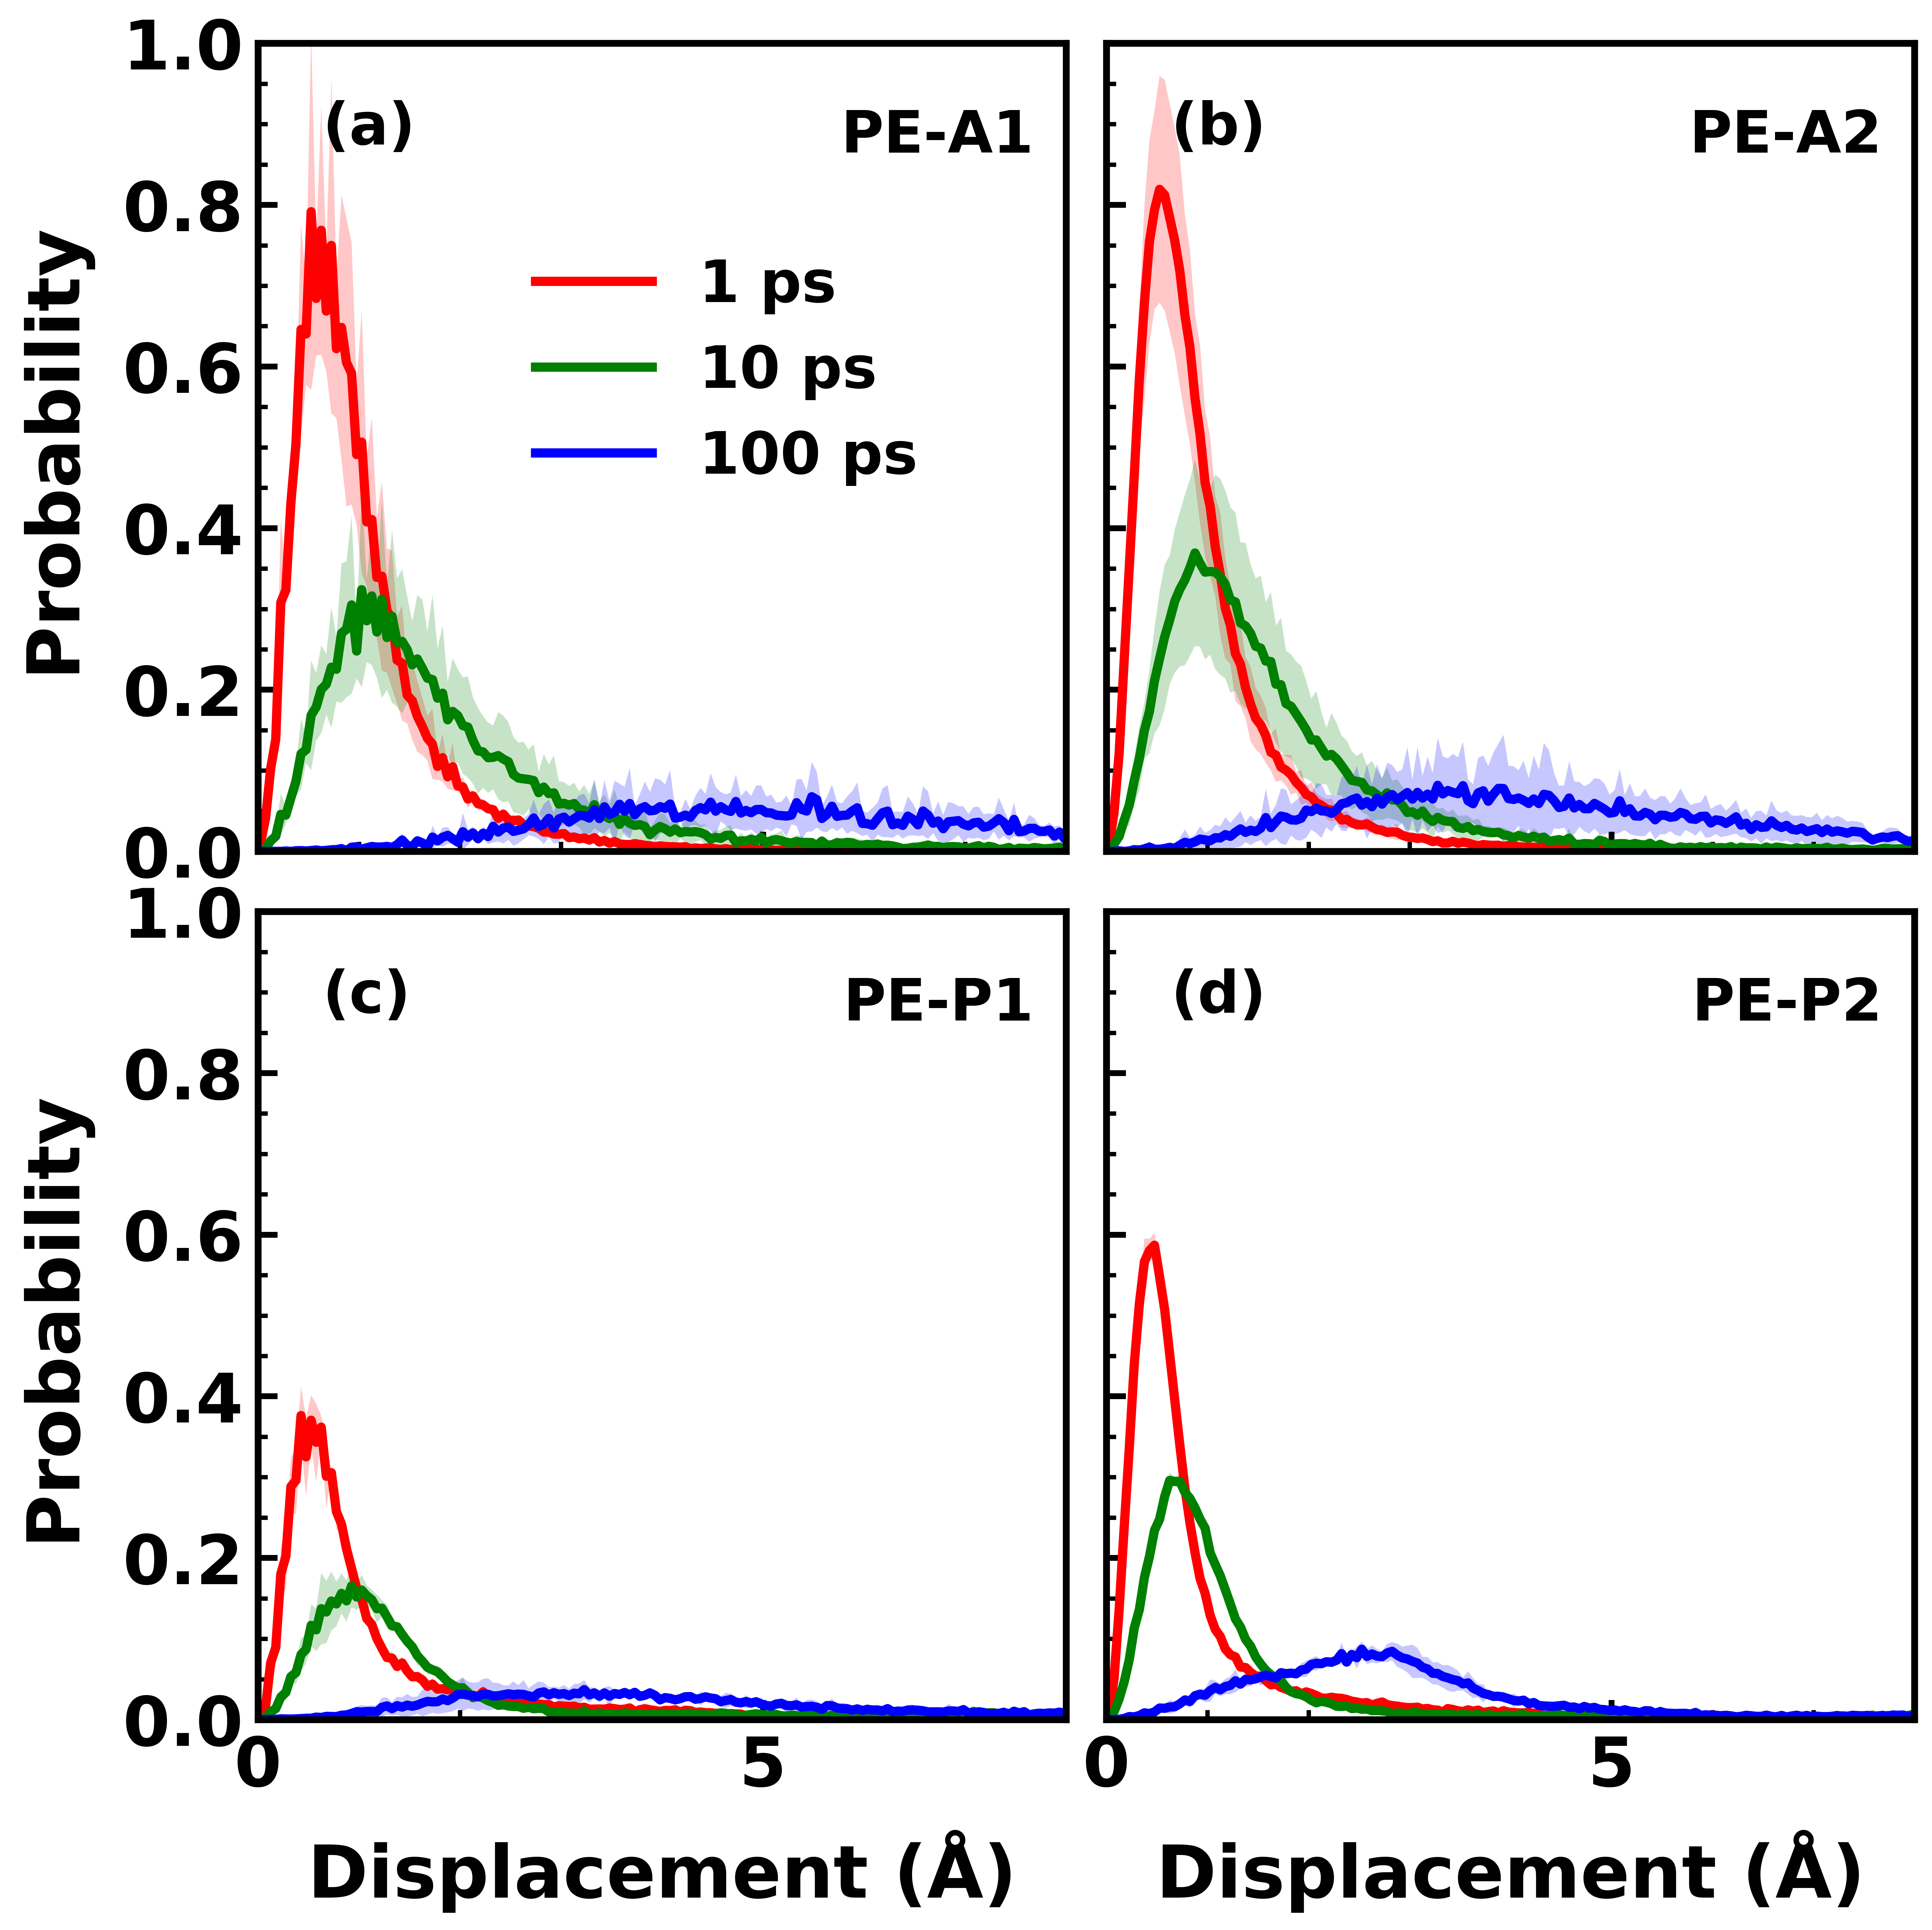


Saved:
displacement_distribution_2x2_ACSbold_1.png
displacement_distribution_2x2_ACSbold_1.pdf


In [4]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# SETTINGS
# =========================================================
BASE = "/blue/jsampath/avemula/Paper1_PE/Polymer"

SYSTEMS = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

TIME_CUTOFF = 1000000
DUMP_EVERY = 1000
TIMESTEP_FS = 1.0
PS_PER_FRAME = (DUMP_EVERY * TIMESTEP_FS) / 1000.0

LAGS_PS = [1, 10, 100]

OUT_PNG = "displacement_distribution_2x2_ACSbold_1.png"
OUT_PDF = "displacement_distribution_2x2_ACSbold_1.pdf"

# =========================================================
# PLOT SETTINGS
# =========================================================
XMIN, XMAX = 0, 8
YMIN, YMAX = 0, 1
BINS = np.linspace(0, 40, 800)

# ACS-like sizing
LABEL_SIZE = 30
TICK_SIZE = 28          # same as axis labels
LEGEND_SIZE = 24
PANEL_TAG_SIZE = 24
SYSTEM_TEXT_SIZE = 24

LINE_W = 3.8            # thicker peak lines
SHADE_ALPHA = 0.22
SPINE_W = 2.8           # thicker borders
TICK_W_MAJOR = 2.4
TICK_W_MINOR = 1.8
TICK_LEN_MAJOR = 8
TICK_LEN_MINOR = 4

colors = {
    1: "red",
    10: "green",
    100: "blue",
}

labels = {
    1: "1 ps",
    10: "10 ps",
    100: "100 ps",
}

# =========================================================
# ACS JOURNAL STYLE
# =========================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": LABEL_SIZE,
    "axes.labelweight": "bold",
    "axes.titlesize": LABEL_SIZE,
    "axes.titleweight": "bold",
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "axes.linewidth": SPINE_W,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": TICK_LEN_MAJOR,
    "ytick.major.size": TICK_LEN_MAJOR,
    "xtick.major.width": TICK_W_MAJOR,
    "ytick.major.width": TICK_W_MAJOR,
    "xtick.minor.size": TICK_LEN_MINOR,
    "ytick.minor.size": TICK_LEN_MINOR,
    "xtick.minor.width": TICK_W_MINOR,
    "ytick.minor.width": TICK_W_MINOR,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

# =========================================================
# READ ONE TRAJECTORY AND KEEP SELECTED ATOM TYPE
# =========================================================
def read_type_positions_from_lammpstrj(filename, atom_type_keep, time_cutoff=None):
    """
    Returns:
        times  : list of timesteps
        frames : list of arrays of shape (n_selected_atoms, 3)
                 using xu, yu, zu coordinates
    """
    times = []
    frames = []

    with open(filename, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break

            if not line.startswith("ITEM: TIMESTEP"):
                continue

            timestep = int(f.readline().strip())
            if time_cutoff is not None and timestep > time_cutoff:
                break

            line = f.readline().strip()
            if "NUMBER OF ATOMS" not in line:
                raise RuntimeError(f"Missing NUMBER OF ATOMS in {filename}")

            natoms = int(f.readline().strip())

            line = f.readline().strip()
            if not line.startswith("ITEM: BOX BOUNDS"):
                raise RuntimeError(f"Missing BOX BOUNDS in {filename}")

            f.readline()
            f.readline()
            f.readline()

            atom_header = f.readline().strip()
            if not atom_header.startswith("ITEM: ATOMS"):
                raise RuntimeError(f"Missing ATOMS header in {filename}")

            cols = atom_header.split()[2:]
            col_index = {c: i for i, c in enumerate(cols)}

            required = ["id", "type", "xu", "yu", "zu"]
            for r in required:
                if r not in col_index:
                    raise RuntimeError(f"{filename} missing required column: {r}")

            id_idx   = col_index["id"]
            type_idx = col_index["type"]
            xu_idx   = col_index["xu"]
            yu_idx   = col_index["yu"]
            zu_idx   = col_index["zu"]

            kept = []
            for _ in range(natoms):
                parts = f.readline().split()
                if int(parts[type_idx]) == atom_type_keep:
                    kept.append([
                        int(parts[id_idx]),
                        float(parts[xu_idx]),
                        float(parts[yu_idx]),
                        float(parts[zu_idx]),
                    ])

            if len(kept) == 0:
                continue

            kept = np.array(kept, dtype=float)

            order = np.argsort(kept[:, 0])
            kept = kept[order]

            times.append(timestep)
            frames.append(kept[:, 1:4])

    if len(frames) == 0:
        raise RuntimeError(f"No usable frames found in {filename}")

    nsel = frames[0].shape[0]
    for i, fr in enumerate(frames):
        if fr.shape[0] != nsel:
            raise RuntimeError(
                f"Selected atom count changes across frames in {filename}: "
                f"frame 0 has {nsel}, frame {i} has {fr.shape[0]}"
            )

    return times, frames


# =========================================================
# COMPUTE DISPLACEMENT DISTRIBUTIONS FOR ONE REPLICA
# =========================================================
def compute_displacement_distributions(frames, lags_ps, ps_per_frame):
    nframes = len(frames)
    results = {}

    for lag_ps in lags_ps:
        lag_frames = int(round(lag_ps / ps_per_frame))

        if lag_frames < 1:
            raise RuntimeError(f"lag_ps={lag_ps} gives lag_frames < 1")
        if nframes <= lag_frames:
            raise RuntimeError(
                f"Not enough frames for {lag_ps} ps displacement: "
                f"need > {lag_frames}, found {nframes}"
            )

        dr_all = []
        for i in range(nframes - lag_frames):
            dxyz = frames[i + lag_frames] - frames[i]
            dr = np.linalg.norm(dxyz, axis=1)
            dr_all.append(dr)

        results[lag_ps] = np.concatenate(dr_all)

    return results


# =========================================================
# PROCESS ONE SYSTEM ACROSS REPLICAS
# =========================================================
def process_system(replica_files, atom_type_keep, time_cutoff, lags_ps, ps_per_frame):
    per_replica_results = []

    for rep_idx, repfile in enumerate(replica_files, start=1):
        print(f"Reading: {repfile}")
        times, frames = read_type_positions_from_lammpstrj(
            repfile,
            atom_type_keep=atom_type_keep,
            time_cutoff=time_cutoff
        )

        print(f"  replica = {rep_idx}")
        print(f"  selected atom type = {atom_type_keep}")
        print(f"  frames read = {len(frames)}")
        print(f"  atoms/frame = {frames[0].shape[0]}")
        print(f"  first timestep = {times[0]}, last timestep = {times[-1]}")

        rep_results = compute_displacement_distributions(
            frames,
            lags_ps=lags_ps,
            ps_per_frame=ps_per_frame
        )

        for lag in lags_ps:
            print(f"    lag {lag} ps : count = {len(rep_results[lag])}")

        per_replica_results.append(rep_results)

    return per_replica_results


# =========================================================
# BUILD HISTOGRAM MEAN/STD ACROSS REPLICAS
# =========================================================
def histogram_mean_std(replica_results_for_one_system, lag_ps, bins):
    hist_list = []

    for rep in replica_results_for_one_system:
        arr = rep[lag_ps]
        hist, edges = np.histogram(arr, bins=bins, density=True)
        hist_list.append(hist)

    hist_array = np.array(hist_list)

    mean_hist = hist_array.mean(axis=0)
    if hist_array.shape[0] > 1:
        std_hist = hist_array.std(axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, mean_hist, std_hist


# =========================================================
# MAIN
# =========================================================
all_results = {}

for sys_name, info in SYSTEMS.items():
    print("\n" + "=" * 70)
    print(f"Processing system: {sys_name}")
    print("=" * 70)

    all_results[sys_name] = process_system(
        replica_files=info["files"],
        atom_type_keep=info["atom_type"],
        time_cutoff=TIME_CUTOFF,
        lags_ps=LAGS_PS,
        ps_per_frame=PS_PER_FRAME
    )

# =========================================================
# CREATE 2x2 PANEL LAYOUT
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 11),   # square figure
    dpi=600,
    sharex=True,
    sharey=True
)

axes = axes.flatten()
system_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]
panel_tags = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, sys_name) in enumerate(zip(axes, system_order)):
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        ax.plot(
            centers,
            mean_hist,
            lw=LINE_W,
            color=colors[lag],
            label=labels[lag]
        )

        ax.fill_between(
            centers,
            np.clip(mean_hist - std_hist, 0, None),
            mean_hist + std_hist,
            color=colors[lag],
            alpha=SHADE_ALPHA,
            linewidth=0
        )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    # panel tag
    ax.text(
        0.08, 0.93, panel_tags[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=PANEL_TAG_SIZE,
        fontweight="bold"
    )

    # system name
    ax.text(
        0.96, 0.92, sys_name,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=SYSTEM_TEXT_SIZE,
        fontweight="bold"
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        labelsize=TICK_SIZE,
        width=TICK_W_MAJOR,
        length=TICK_LEN_MAJOR,
        top=False,
        right=False,
        pad=6
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        width=TICK_W_MINOR,
        length=TICK_LEN_MINOR,
        top=False,
        right=False
    )

    ax.minorticks_on()

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_W)

    # square panel
    ax.set_box_aspect(1)

# Left column y-labels only
axes[0].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=14)
axes[2].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=14)

# Bottom row x-labels only
axes[2].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=12)
axes[3].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=12)

# Hide top-row x tick labels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)

# Hide right-column y tick labels
axes[1].tick_params(labelleft=False)
axes[3].tick_params(labelleft=False)

# Legend only in first panel
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.58, 0.80),
    ncol=1,
    frameon=False,
    prop={"weight": "bold", "size": LEGEND_SIZE}
)

# Tight ACS-like spacing
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05,
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.98
)

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_PDF)